 ## **Kualitas Udara Antar Negara Tahun 2023**

* **Kelompok: Kelompok 14**
* **Nama dan NRP:**
    1. Dennis Immanuel Stevano Baskoro - 5027261096
    2. Eric Fahrezi Hutagalung - 5027261138
    3. Fikri Taqiyuddin Althaf - 5027261077
* **Topik:** Eksplorasi Data tentang Kualitas Udara Antar Negara Tahun 2023.

**Latar Belakang dan Pertanyaan**


Data ini menarik karena memperlihatkan kontras polusi dan cuaca di kota-kota lintas benua. Terlihat dinamika unik antarwilayah, seperti Rio de Janeiro yang memiliki PM2.5 dan O3 tinggi pada kelembapan rendah (29,30%), dimana hal ini berbanding terbalik dengan kota Mumbai yang mencatatkan PM10 tertinggi pada kelembapan ekstrem (99,97%).


**Pertanyaan:** 
1. Berapa rata-rata, median, dan seberapa besar variasi (standar deviasi) tingkat PM2.5 di setiap kota?
2. Apakah kota dengan rata-rata kelembapan udara tinggi cenderung memiliki kadar PM10 dan NO2 yang lebih rendah dibanding kota bernilai kelembapan rendah?
3. Jenis polutan mana (PM2.5, PM10, NO2, SO2, CO, atau O3) yang memiliki rentang dan persebaran nilai paling bervariasi secara global?

## 1. Memuat Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("global_air_quality_data_10000.csv")
print(df.shape)   # (jumlah baris, jumlah kolom)
df.head()

(10000, 12)


,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Bangkok,Thailand,2023-03-19,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,Istanbul,Turkey,2023-02-16,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,Rio de Janeiro,Brazil,2023-11-13,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,Mumbai,India,2023-03-16,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,Paris,France,2023-04-04,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16


## 2. Deskripsi Data dan Kamus Data

**Deskripsi Data**

* Sumber data dan lisensi: (https://www.kaggle.com/datasets/waqi786/global-air-quality-dataset), dengan lisensi Apache 2.0.
* Pengumpulan data: oleh Waqar Ali, data kualitas udara ini dikumpulkan dari beberapa stasiun pemantauan resmi yang berlokasi di masing-masing kota. Pengukuran dicatat secara berkala dan dikompilasi untuk membentuk himpunan data (dataset) komprehensif yang mencakup berbagai polutan serta faktor lingkungan. Data tersebut kemudian dibersihkan dan diformat untuk memastikan agar data siap digunakan untuk analisis. Data tersebut dikumpulkan dari berbagai sumber terpercaya, termasuk lembaga lingkungan hidup pemerintah dan organisasi internasional yang berfokus pada pemantauan kualitas udara. Data ini telah diagregasi dan diproses untuk memastikan konsistensi serta akurasinya. 
* Jumlah baris dan kolom: 10.000 baris dan 12 kolom.

**Kamus Data**

| Kolom | Arti | Jenis variabel | Skala | Satuan | Contoh |
| --- | --- | --- | --- | --- | --- |
| **City** | Nama kota lokasi pengukuran | Kualitatif | Nominal | - | Bangkok |
| **Country** | Nama negara lokasi kota berada | Kualitatif | Nominal | - | Thailand |
| **Date** | Tanggal waktu perekaman data | Kuantitatif kontinu | Interval | YYYY-MM-DD | 2023-03-19 |
| **PM2.5** | Konsentrasi partikel halus (<= 2.5 µm) di udara | Kuantitatif kontinu | Rasio | µg/m³ | 86.57 |
| **PM10** | Konsentrasi partikel kasar (<= 10 µm) di udara | Kuantitatif kontinu | Rasio | µg/m³ | 25.19 |
| **NO2** | Konsentrasi gas Nitrogen Dioksida di udara | Kuantitatif kontinu | Rasio | µg/m³ | 99.88 |
| **SO2** | Konsentrasi gas Sulfur Dioksida di udara | Kuantitatif kontinu | Rasio | µg/m³ | 30.63 |
| **CO** | Konsentrasi gas Karbon Monoksida di udara | Kuantitatif kontinu | Rasio | mg/m³ | 4.46 |
| **O3** | Konsentrasi gas Ozon Permukaan di udara | Kuantitatif kontinu | Rasio | µg/m³ | 36.29 |
| **Temperature** | Suhu udara saat pengukuran | Kuantitatif kontinu | Interval | °C | 17.67 |
| **Humidity** | Kelembapan relatif udara saat pengukuran | Kuantitatif kontinu | Rasio | % | 59.35 |
| **Wind Speed** | Kecepatan angin saat pengukuran | Kuantitatif kontinu | Rasio | m/s | 13.76 |

## 3. Pemeriksaan Kualitas Data

In [3]:
informasi = df.info()                 # tipe data setiap kolom
kosong = df.isna().sum()           # jumlah data kosong per kolom
dobel = df.duplicated().sum()     # jumlah baris duplikat

informasi, kosong, dobel

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         10000 non-null  str    
 1   Country      10000 non-null  str    
 2   Date         10000 non-null  str    
 3   PM2.5        10000 non-null  float64
 4   PM10         10000 non-null  float64
 5   NO2          10000 non-null  float64
 6   SO2          10000 non-null  float64
 7   CO           10000 non-null  float64
 8   O3           10000 non-null  float64
 9   Temperature  10000 non-null  float64
 10  Humidity     10000 non-null  float64
 11  Wind Speed   10000 non-null  float64
dtypes: float64(9), str(3)
memory usage: 937.6 KB


(None,
 City           0
 Country        0
 Date           0
 PM2.5          0
 PM10           0
 NO2            0
 SO2            0
 CO             0
 O3             0
 Temperature    0
 Humidity       0
 Wind Speed     0
 dtype: int64,
 np.int64(0))

### Interpretasi Kualitas Data

Berdasarkan hasil pengecekan menggunakan `df.info()`, `df.isna().sum()`, dan `df.duplicated().sum()`, diperoleh temuan sebagai berikut:

**1. Tipe Data**

Secara umum, tipe data sudah sesuai dengan kamus data. Kolom City, Country, dan Date bertipe teks (`str`), sedangkan kolom numerik PM2.5, PM10, NO2, SO2, CO, O3, Temperature, Humidity, dan Wind Speed sudah bertipe (`float64`). Kolom `Date` tidak dikonversi ke `datetime` karena analisis pada tugas ini tidak berbasis waktu. Tidak ditemukan angka yang salah terbaca sebagai teks.

**2. Data Kosong**

Hasil pengecekan menunjukkan terdapat **0** data kosong di seluruh kolom dataset (setiap kolom terdapat 10.000 baris).

**3. Data Duplikat**

Hasil pengecekan menunjukkan ada sebanyak **0** baris data duplikat, yaitu baris yang isinya sama persis dengan baris lainnya.

**Kesimpulan Singkat**

Secara keseluruhan, dataset sudah bersih dan konsisten. Struktur data rapi, tipe data sesuai, dan tidak ada data kosong maupun duplikat. Pembersihan data tidak diperlukan sehingga data siap digunakan untuk tahap analisis selanjutnya.

## 4. Statistik Deskriptif Variabel Numerik

In [4]:
kolom = df[["PM2.5", "PM10", "NO2", "SO2", "CO", "O3","Temperature","Humidity","Wind Speed"]]

statistik = pd.DataFrame({
    'rata-rata': kolom.mean(),
    'median': kolom.median(),
    'modus': kolom.mode().iloc[0],
    'var': kolom.var(),
    'std': kolom.std(),
    'Q1': kolom.quantile(0.25),
    'Q3': kolom.quantile(0.75),
    'IQR': kolom.quantile(0.75) - kolom.quantile(0.25),
})
statistik

,rata-rata,median,modus,var,std,Q1,Q3,IQR
PM2.5,77.448439,77.725,26.59,1757.946396,41.927871,41.1850,113.3925,72.2075
PM10,104.438161,103.690,64.70,3031.867434,55.062396,57.1375,152.2650,95.1275
NO2,52.198649,52.100,10.63,746.409159,27.320490,28.3475,75.7050,47.3575
SO2,25.344490,25.350,20.44,198.561750,14.091194,13.1900,37.5000,24.3100
CO,5.047984,5.090,2.38,8.137468,2.852625,2.5600,7.4800,4.9200
O3,106.031643,106.055,10.16,3033.954602,55.081345,58.3800,153.9825,95.6025
Temperature,14.897150,14.755,35.24,208.623350,14.443800,2.2575,27.3825,25.1250
Humidity,55.078579,55.080,55.79,675.076397,25.982232,32.5275,77.4425,44.9150
Wind Speed,10.231636,10.260,7.72,31.726498,5.632628,5.2900,15.0700,9.7800


### Interpretasi Statistik Deskriptif

Kita memilih 4 kolom numerik untuk dijelaskan lebih lanjut: **PM2.5**, **PM10**, **NO2** (satuan µg/m³), dan **Humidity** (%).

### Interpretasi

**1. PM2.5 (µg/m³)**
Rata-rata konsentrasi PM2.5 adalah 77,45 µg/m³, sedangkan mediannya 77,72 µg/m³. Selisih keduanya sangat kecil (hanya 0,27 µg/m³), artinya distribusi data **cenderung simetris (mendekati normal)**, bukan menceng (berbentuk kurva). Nilai maksimum 149,98 µg/m³ dan minimum 5,02 µg/m³ menunjukkan rentang data yang lebar (Range = 144,96 µg/m³). Simpangan baku sebesar 41,93 µg/m³ menandakan variasi konsentrasi PM2.5 antar-kota cukup tinggi.

**2. PM10 (µg/m³)**
Rata-rata PM10 adalah 104,44 µg/m³ dengan median 103,69 µg/m³. Pola serupa dengan PM2.5: selisih mean vs median hanya 0,75 µg/m³, sehingga distribusinya juga **relatif simetris**. Nilai maksimum 200,00 µg/m dan minimum 10,00 µg/m³ menunjukkan range yang lebar (190,00 µg/m³). Simpangan baku 55,06 µg/m³ dan IQR 95,13 µg/m³ menandakan sebaran data PM10 lebih lebar dibanding PM2.5, karena PM10 mencakup partikel dengan ukuran lebih bervariasi.

**3. NO2 (µg/m³)**
Rata-rata konsentrasi NO2 adalah 52,20 µg/m³ dengan median 52,10 µg/m³ Selisih keduanya sangat kecil (hanya 0,10 µg/m³), artinya distribusi data cenderung **simetris**, tidak menceng ke satu sisi. Nilai maksimum 100,00 µg/m³ dan minimum 5,01 µg/m³ menunjukkan rentang data yang lebar (Range = 94,99 µg/m³). Simpangan baku sebesar 27,32 µg/m³ dan IQR 47,36 µg/m³ (Q1 = 28,35 dan Q3 = 75,71) menandakan variasi NO2 cukup tinggi. Simpangan baku NO2 lebih kecil daripada PM2.5 dan PM10, itu karena skala NO2 lebih kecil. 

**4. Humidity (%)**
Rata-rata kelembapan adalah 55,08% dan mediannya juga 55,08%. Selisih keduanya nyaris nol (kurang dari 0,01%), artinya distribusi data **sangat simetris**. Nilai maksimum 99,99% dan minimum **10,01% menunjukkan rentang data yang lebar (Range = 89,98%), dengan nilai tertinggi mendekati batas atas kelembapan relatif, yaitu 100%. Simpangan baku sebesar **25,98% dan IQR **44,92% (Q1 = 32,53% dan Q3 = 77,44%) menandakan kelembapan tersebar luas, dari kondisi cukup kering sampai hampir jenuh uap air.

### Perbandingan Rata-rata vs Median

Pada keempat kolom, selisih antara mean dan median **sangat kecil**. Ini berarti distribusi data **cenderung simetris** dan **tidak memiliki outlier ekstrem** yang signifikan. Dengan demikian, **mean maupun median sama-sama representatif** digunakan sebagai ukuran pemusatan.

Kondisi ini berbeda dari ekspektasi umum data polusi udara yang biasanya menceng ke kanan (mean > median). Kemungkinan hal ini terjadi karena dataset telah melalui proses agregasi dan pembersihan sebelumnya, sehingga nilai-nilai ekstrem sudah dinormalisasi.

## 5. Tabel Frekuensi Variabel Kategorik

**Tabel frekuensi dan persentase kolom `City`**

In [5]:
ringkasan_kategori = pd.DataFrame({
    'Frekuensi': df['City'].value_counts(),
    'Persentase': df['City'].value_counts(normalize=True) * 100
})
ringkasan_kategori

,Frekuensi,Persentase
City,,
Mumbai,540,5.40
Seoul,522,5.22
Johannesburg,521,5.21
Dubai,520,5.20
Berlin,519,5.19
Toronto,518,5.18
Madrid,518,5.18
Cairo,510,5.10
Bangkok,499,4.99


### Kategori Paling Sering Muncul (Modus)

Berdasarkan hasil `value_counts()`, kategori yang paling sering muncul (modus) pada kolom `City` adalah **Mumbai** dengan frekuensi **540** kemunculan, atau sekitar **5,40**% dari total 10.000 data.

### Diagram Batang: Frekuensi Data per Kota

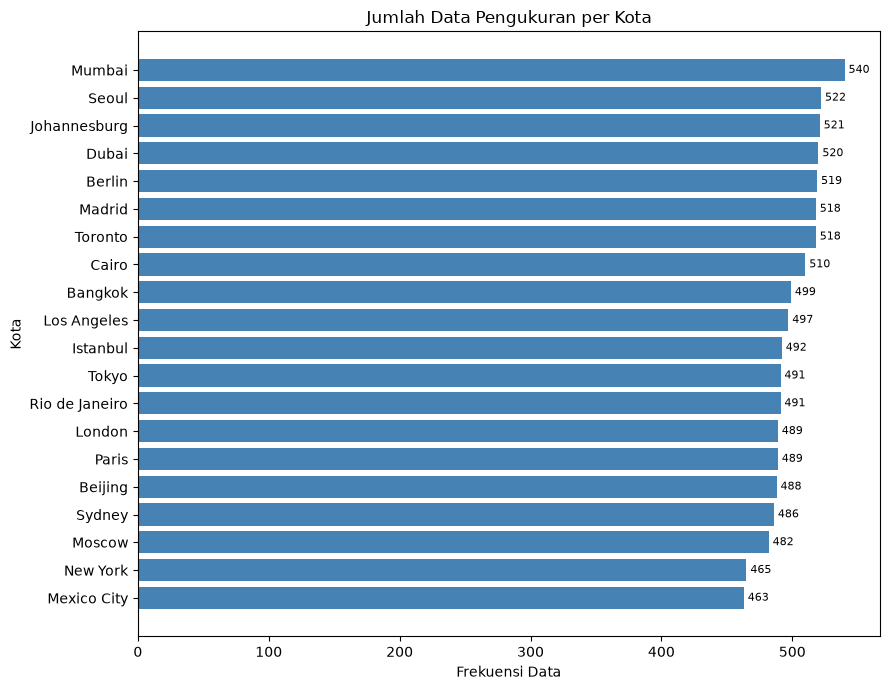

In [6]:
diagram_bobok = ringkasan_kategori["Frekuensi"].sort_values()

plt.figure(figsize=(9, 7))
plt.barh(diagram_bobok.index, diagram_bobok.values, color="steelblue")
for i, v in enumerate(diagram_bobok.values):
    plt.text(v + 3, i, str(v), va="center", fontsize=8)   # tulis angka di ujung batang
plt.title("Jumlah Data Pengukuran per Kota")
plt.xlabel("Frekuensi Data")
plt.ylabel("Kota")
plt.tight_layout()
plt.show()

### Interpretasi

Distribusi frekuensi antar kota pada dataset ini **relatif merata**, tidak ada satu kota yang mendominasi secara ekstrem. Kota dengan frekuensi tertinggi (modus) hanya menyumbang sekitar **5,40**% dari total data, sementara kota lain berada di kisaran 4,63% sampai 5,22%, atau sekitar 5% untuk setiap kota (20).

Hal ini bisa terjadi karena dataset merupakan hasil agregasi dari berbagai stasiun pemantauan resmi di banyak negara (sesuai deskripsi dataset), sehingga setiap kota menyumbang proporsi data yang kurang lebih seimbang. Jika ada kota yang frekuensinya jauh lebih tinggi, itu bisa menandakan kota tersebut memiliki lebih banyak stasiun pemantauan atau periode pencatatan yang lebih panjang.

## 7. Pertanyaan 1: Sebaran Data PM2.5 per Kota

In [7]:
pm25_kota = df.groupby("City")["PM2.5"].agg(["mean", "median", "std"]).round(2)
pm25_kota.sort_values("mean", ascending=False)

,mean,median,std
City,,,
Dubai,80.01,81.24,43.04
Sydney,78.93,82.73,42.51
Mumbai,78.90,77.59,42.73
Tokyo,78.87,83.81,40.29
Mexico City,78.86,77.62,41.17
Beijing,78.63,80.18,42.39
Moscow,77.88,75.87,41.69
New York,77.86,80.86,41.80
Toronto,77.83,79.08,41.99


### Diagram Batang: Rata-rata, Median, dan Standar Deviasi PM2.5 per Kota

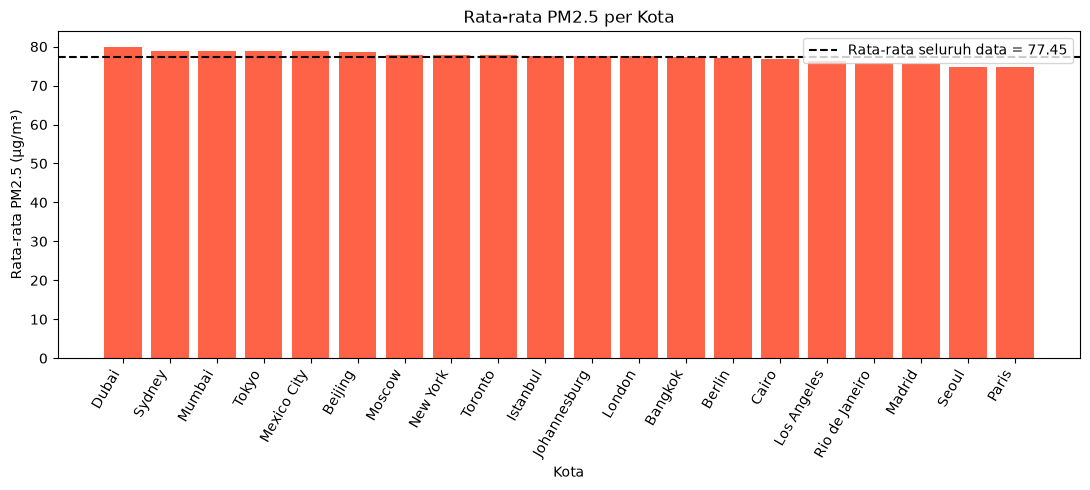

In [8]:
# Diagram batang 2: rata-rata PM2.5 per kota (Pertanyaan 1)
batang_pm25 = pm25_kota["mean"].sort_values(ascending=False)

plt.figure(figsize=(11, 5))
plt.bar(batang_pm25.index, batang_pm25.values, color="tomato")
plt.axhline(df["PM2.5"].mean(), color="black", linestyle="--",
            label=f"Rata-rata seluruh data = {df['PM2.5'].mean():.2f}")
plt.title("Rata-rata PM2.5 per Kota")
plt.xlabel("Kota")
plt.ylabel("Rata-rata PM2.5 (µg/m³)")
plt.xticks(rotation=60, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretasi Diagram Batang Rata-Rata PM2.5 per Kota

Rata-rata PM2.5 tertinggi ada di Dubai (80,01 µg/m³) dan terendah di Paris (74,69 µg/m³), selisih hanya sekitar 5,3 µg/m³. Semua batang mendekati garis rata-rata keseluruhan (77,45 µg/m³), sehingga tidak ada kota yang jauh lebih tercemar dibandingkan kota lain.

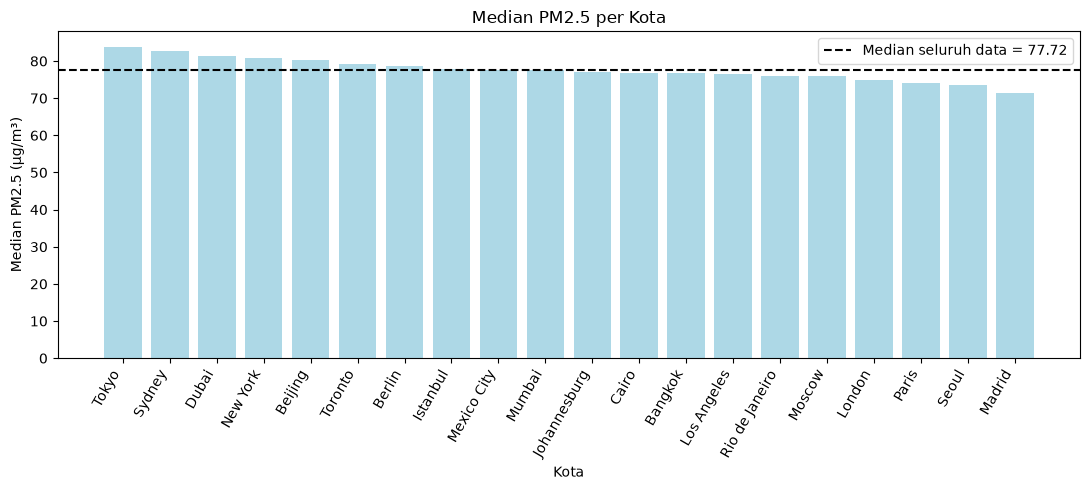

In [9]:
# Diagram batang 2: median PM2.5 per kota (Pertanyaan 1)
median_pm25 = pm25_kota["median"].sort_values(ascending=False)

plt.figure(figsize=(11, 5))
plt.bar(median_pm25.index, median_pm25.values, color="lightblue")
plt.axhline(df["PM2.5"].median(), color="black", linestyle="--",
            label=f"Median seluruh data = {df['PM2.5'].median():.2f}")
plt.title("Median PM2.5 per Kota")
plt.xlabel("Kota")
plt.ylabel("Median PM2.5 (µg/m³)")
plt.xticks(rotation=60, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretasi Diagram Batang Median PM2.5 per Kota

Median PM2.5 tertinggi ada di Tokyo (81.24 µg/m³) dan terendah di Madrid (73.96 µg/m³), selisih hanya sekitar 7,28 µg/m³. Semua batang mendekati garis median keseluruhan (77,72 µg/m³), sehingga jumlah sebaran PM2.5 per kota hampir mirip. 


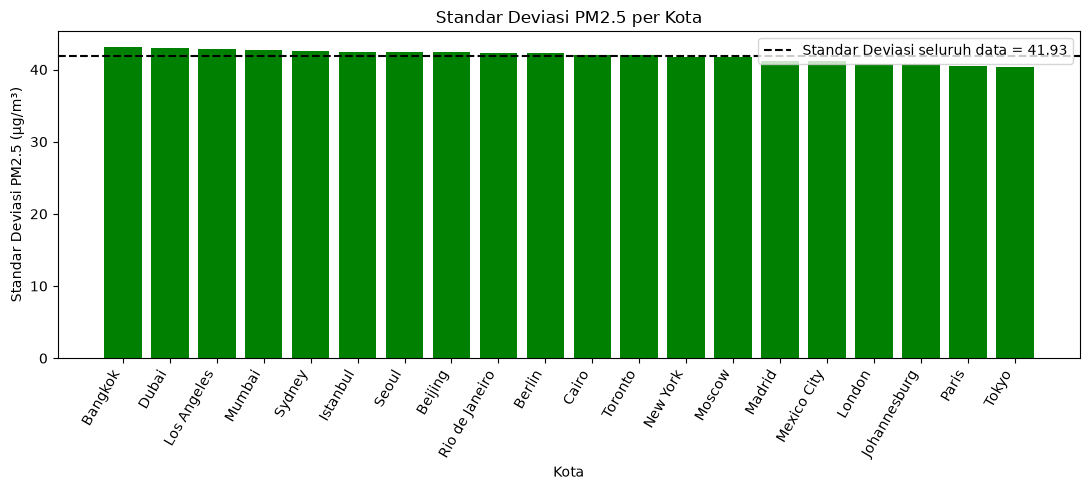

In [14]:
# Diagram batang 2: Standar Deviasi PM2.5 per kota (Pertanyaan 1)
std_pm25 = pm25_kota["std"].sort_values(ascending=False)

plt.figure(figsize=(11, 5))
plt.bar(std_pm25.index, std_pm25.values, color="green")
plt.axhline(df["PM2.5"].std(), color="black", linestyle="--",
            label=f"Standar Deviasi seluruh data = {df['PM2.5'].std():.2f}")
plt.title("Standar Deviasi PM2.5 per Kota")
plt.xlabel("Kota")
plt.ylabel("Standar Deviasi PM2.5 (µg/m³)")
plt.xticks(rotation=60, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretasi Diagram Batang Standar Deviasi PM2.5 per Kota

Standar Deviasi PM2.5 tertinggi ada di Bangkok (43.04 µg/m³) dan terendah di Tokyo (40.52 µg/m³), selisih hanya sekitar 2,52 µg/m³. Semua batang mendekati garis standar deviasi keseluruhan (41,93 µg/m³), sehingga semua kota memiliki siklus PM2.5 yang bervariasi setiap harinya. 

## 8. Pertanyaan 2: Penaruh Kelembapan Terhadap PM10 dan NO2

In [19]:
df = pd.read_csv("global_air_quality_data_10000.csv")
kota = df.groupby("City")[["Humidity", "PM10", "NO2"]].mean().round(2)
median_hum = kota["Humidity"].median()
kota["Kategori_Kelembapan"] = kota["Humidity"].apply(
    lambda x: "Tinggi" if x >= median_hum else "Rendah"
)
kota.groupby("Kategori_Kelembapan")[["PM10", "NO2"]].mean().round(2)

,PM10,NO2
Kategori_Kelembapan,,
Rendah,104.39,52.12
Tinggi,104.46,52.25


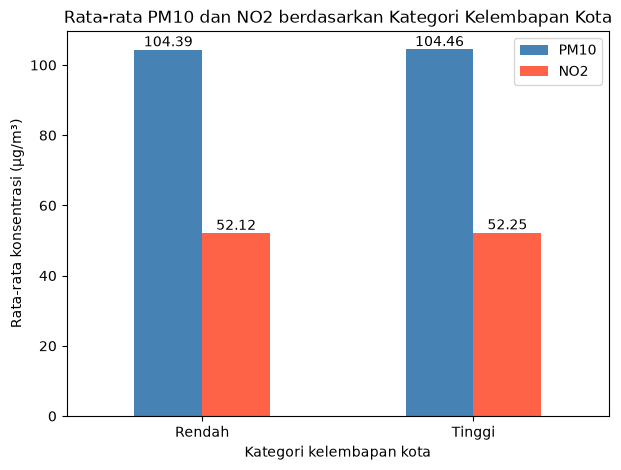

In [12]:
rata = kota.groupby("Kategori_Kelembapan")[["PM10", "NO2"]].mean().round(2).loc[["Rendah", "Tinggi"]]

ax = rata.plot(kind="bar", figsize=(7, 5), color=["steelblue", "tomato"], rot=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f")   # tulis angka di atas batang

plt.title("Rata-rata PM10 dan NO2 berdasarkan Kategori Kelembapan Kota")
plt.xlabel("Kategori kelembapan kota")
plt.ylabel("Rata-rata konsentrasi (µg/m³)")
plt.show()


## 9. Pertanyaan 3: Variasi Antar Polutan

In [15]:
polutan = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]
var_polutan = pd.DataFrame({
    "mean": df[polutan].mean(),
    "median": df[polutan].median(),
    "std": df[polutan].std(),
    "range": df[polutan].max() - df[polutan].min(),
    "IQR": df[polutan].quantile(0.75) - df[polutan].quantile(0.25),
    "CV (%)": df[polutan].std() / df[polutan].mean() * 100,   # membandingkan variasi lintas satuan
}).round(2)
var_polutan.sort_values("CV (%)", ascending=False)

,mean,median,std,range,IQR,CV (%)
CO,5.05,5.09,2.85,9.90,4.92,56.51
SO2,25.34,25.35,14.09,48.99,24.31,55.60
PM2.5,77.45,77.72,41.93,144.96,72.21,54.14
PM10,104.44,103.69,55.06,190.00,95.13,52.72
NO2,52.20,52.10,27.32,94.99,47.36,52.34
O3,106.03,106.06,55.08,189.96,95.60,51.95


Catatan: CO berada pada skala mg/m³ sedangkan polutan lain µg/m³, sehingga std dan range tidak bisa dibandingkan langsung. **CV (koefisien variasi)** dipakai agar perbandingannya adil.

### Diagram Batang: Koefisien Variasi Polutan

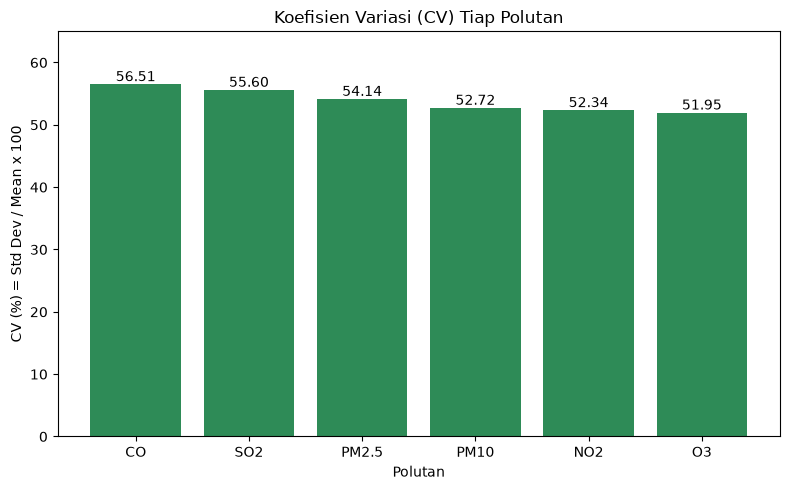

In [16]:
# Diagram batang 3: koefisien variasi (CV) tiap polutan (Pertanyaan 3)
cv = var_polutan["CV (%)"].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(cv.index, cv.values, color="seagreen")
for i, v in enumerate(cv.values):
    plt.text(i, v + 0.5, f"{v:.2f}", ha="center")   # nilai CV di atas batang
plt.title("Koefisien Variasi (CV) Tiap Polutan")
plt.xlabel("Polutan")
plt.ylabel("CV (%) = Std Dev / Mean x 100")
plt.ylim(0, 65)
plt.tight_layout()
plt.show()

**Interpretasi Diagram Batang CV Polutan**

CO memiliki CV tertinggi (56,51%) dan O3 memiliki CV terendah (51,95%). Selisih antar-polutan hanya sekitar 4,6 persen, sehingga keenam polutan memiliki tingkat variasi relatif yang hampir sama. CV dipakai karena satuan CO (mg/m³) berbeda dari polutan lain (µg/m³), sehingga std dan range mentah tidak bisa dibandingkan langsung.

### Histogram Distribusi Variabel Numerik

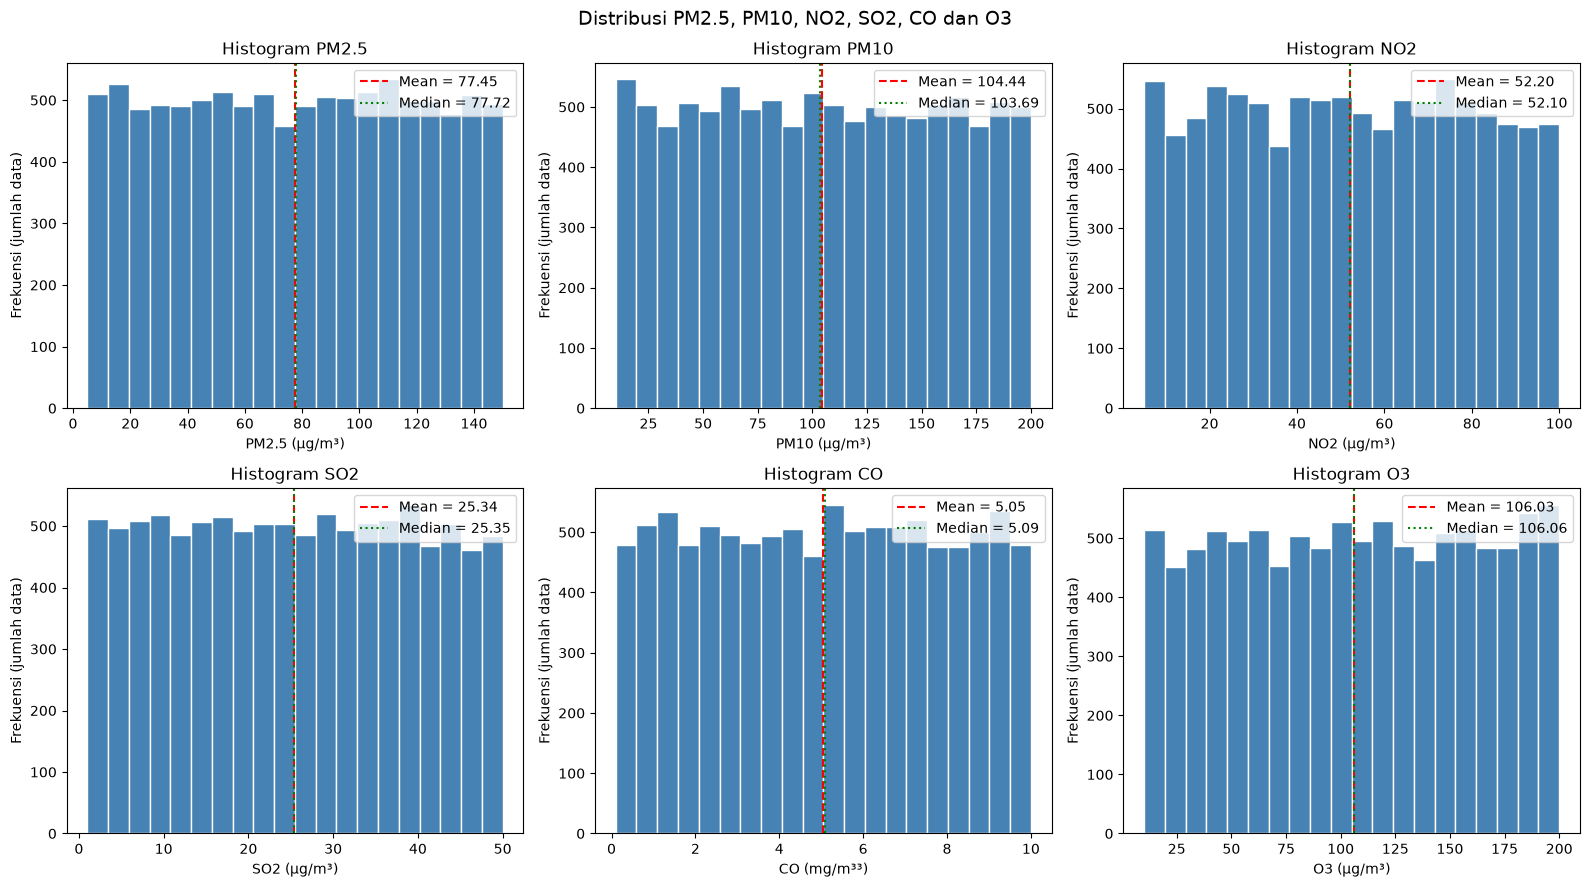

In [17]:
# Histogram distribusi 6 kolom numerik 
# Garis merah = mean
# Garis hijau = median
kolom_hist = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]
satuan = {"PM2.5": "µg/m³", "PM10": "µg/m³", "NO2": "µg/m³",
          "SO2": "µg/m³", "CO": "mg/m³³", "O3": "µg/m³"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, k in zip(axes, kolom_hist):
    ax.hist(df[k], bins=20, color="steelblue", edgecolor="white")
    ax.axvline(df[k].mean(), color="red", linestyle="--", label=f"Mean = {df[k].mean():.2f}")
    ax.axvline(df[k].median(), color="green", linestyle=":", label=f"Median = {df[k].median():.2f}")
    ax.set_title(f"Histogram {k}")
    ax.set_xlabel(f"{k} ({satuan[k]})")
    ax.set_ylabel("Frekuensi (jumlah data)")
    ax.legend()

fig.suptitle("Distribusi PM2.5, PM10, NO2, SO2, CO dan O3", fontsize=14)
plt.tight_layout()
plt.show()

**Interpretasi Histogram**

Kelima variabel memiliki bentuk distribusi yang mendekati **datar (seragam)**: batang histogram kurang lebih sama tinggi di sepanjang rentang nilai dan tidak berbentuk lonceng. Ini sejalan dengan statistik deskriptif: garis mean dan median hampir berimpit (misalnya PM2.5 77,45 vs 77,72 µg/m³; Humidity 55,08 vs 55,08 %) dan berada di tengah rentang nilai (suhu -10 sampai 40 °C dengan mean 14,90 °C). Tidak ada ekor panjang ke satu sisi sehingga distribusi bersifat simetris dan tidak menceng. Artinya setiap nilai dalam rentangnya kurang lebih sama sering muncul, pola yang jarang ditemukan pada data kualitas udara nyata.

### Boxplot Sebaran Polutan

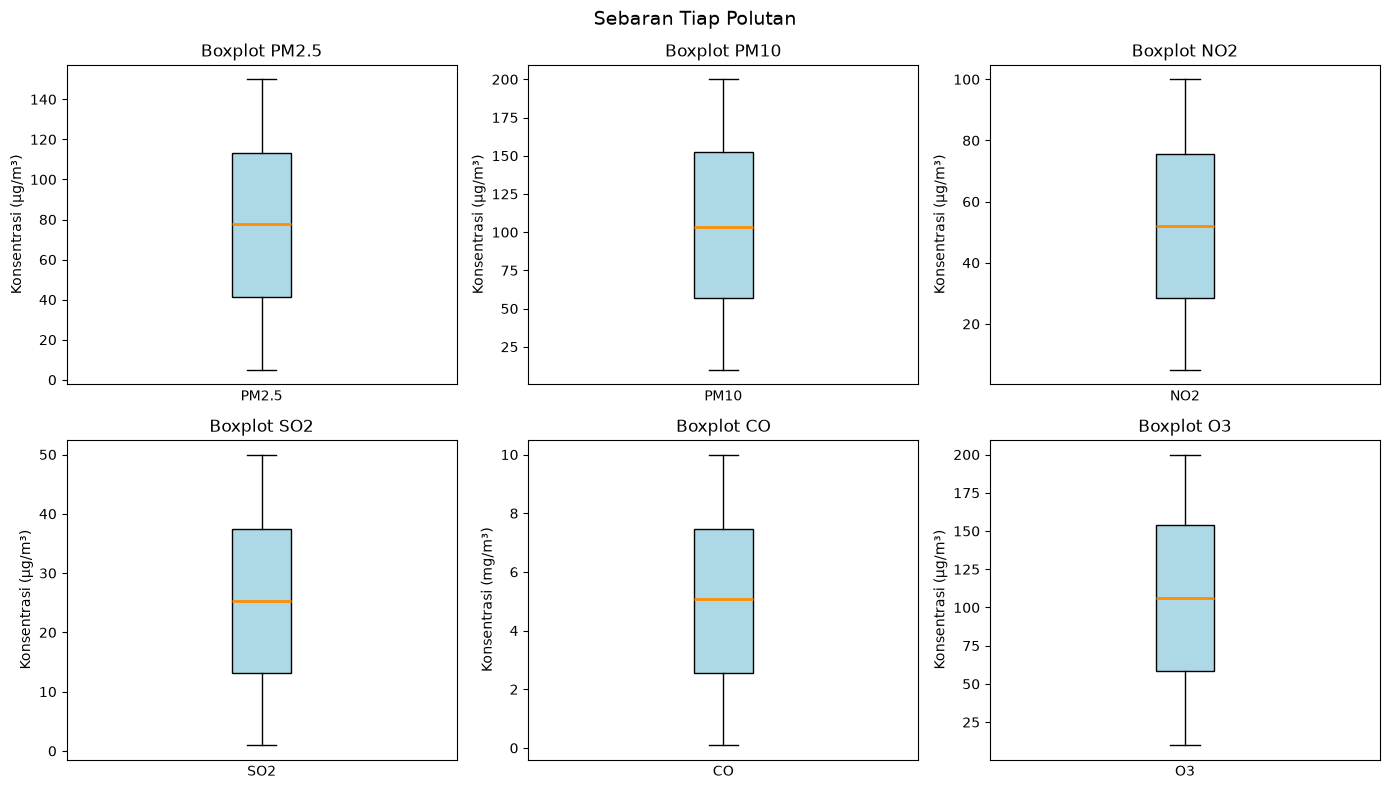

In [18]:
# Boxplot tiap polutan (sumbu-y dibuat terpisah karena satuan dan skala berbeda)
satuan_polutan = {"PM2.5": "µg/m³", "PM10": "µg/m³", "NO2": "µg/m³",
                  "SO2": "µg/m³", "CO": "mg/m³", "O3": "µg/m³"}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, p in zip(axes.ravel(), polutan):
    ax.boxplot(df[p], patch_artist=True, boxprops=dict(facecolor="lightblue"),
               medianprops=dict(color="darkorange", linewidth=2))
    ax.set_title(f"Boxplot {p}")
    ax.set_xlabel(p)
    ax.set_ylabel(f"Konsentrasi ({satuan_polutan[p]})")
    ax.set_xticks([])
fig.suptitle("Sebaran Tiap Polutan", fontsize=14)
plt.tight_layout()
plt.show()

**Interpretasi Boxplot**

Pada keenam polutan, kotak (IQR) berada di tengah rentang nilai dan garis median (oranye) berada dekat pertengahan kotak, artinya sebaran simetris. Kedua whisker menjangkau nilai minimum dan maksimum **tanpa ada titik pencilan (outlier)**, sehingga tidak ada kejadian ekstrem yang menonjol. Ini konsisten dengan tabel: IQR tiap polutan sekitar setengah dari range-nya (PM2.5: 72,21 dari 144,96; O3: 95,60 dari 189,96). Karena skala tiap panel berbeda (CO dalam mg/m³), tinggi kotak antar-panel tidak boleh dibandingkan langsung; untuk perbandingan variasi gunakan CV pada diagram batang sebelumnya.

## 10. Kesimpulan

**Pertanyaan 1: rata-rata, median, dan standar deviasi PM2.5 per kota**

Rata-rata PM2.5 hampir sama di semua kota, sekitar 74,69 µg/m³ sampai 80,01 µg/m³, selisih hanya sekitar 5 µg/m³. Mediannya berkisar 71,44 sampai 83,81. Standar deviasinya lumayan besar, sekitar 40-43 di setiap kota. Artinya perbedaan konsentrasi PM2.5 di dalam satu kota setiap harinya jauh lebih besar daripada perbedaan konsentrasi PM2.5 antar kota, sehingga tidak ada kota yang benar-benar terlihat lebih tercemar.

**Pertanyaan 2: apakah kota berkelembapan tinggi memiliki PM10 dan NO2 lebih rendah**

Dugaan tersebut tidak terbukti.

| Kategori kelembapan | Rata-rata PM10 | Rata-rata NO2 |
|:---|---:|---:|
| Rendah | 104,39 | 52,12 |
| Tinggi | 104,46 | 52,25 |

Selisihnya nyaris nol. Jadi kelembapan tidak berpengaruh terhadap kadar PM10 maupun NO2 dalam data ini.

**Pertanyaan 3: polutan dengan rentang dan persebaran paling bervariasi**

Berdasarkan std dan range mentah, PM10 dan O3 tampak paling bervariasi (std sekitar 55 dan range sekitar 190). Namun itu tidak valid karena skala nilainya lebih besar daripada CO. Perbandingan yang adil memakai koefisien variasi (CV):

| Polutan | CV (%) |
|---|---|
| CO | 56,51 |
| SO2 | 55,60 |
| PM2.5 | 54,14 |
| PM10 | 52,72 |
| NO2 | 52,34 |
| O3 | 51,95 |

CO menjadi polutan yang paling bervariasi dan O3 yang paling stabil, tetapi selisih antar polutan sangat kecil (sekitar 52-57%).


| AI yang digunakan | Claude, Gemini, Deepseek |
|---|---|
| Digunakan untuk | membantu menyusun kerangka kode pandas dan matplotlib (tabel dan diagram), membantu menjelaskan fungsi & command yang ada di ptyhon, membantu mencari penyebab error saat menjalankan notebook, dan menyarankan koefisien variasi (CV) untuk membandingkan variasi antar-polutan yang satuannya berbeda |
| Yang Dipelajari | Pemahaman kode untuk membuat tabel & grafik, struktur markdown dan code in jupyter notebook |
| Verifikasi kelompok | seluruh notebook dijalankan ulang dengan Restart & Run All, angka pada interpretasi dicocokkan dengan output tabel, dan setiap anggota memahami serta dapat menjelaskan setiap sel kode |